<a href="https://colab.research.google.com/github/ga426553-sudo/Classification-of-Breast-Cancer-Subtypes-machine-learning---CuMiDa-22820/blob/main/XGBoost_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cuarto código - Cáncer de Mama 🌸

**Implementación de XGBoost para Clasificación de Cáncer de Mama**

### Conectar con Google Drive 🌺

In [22]:
# ============================================
# CÓDIGO 4: XGBOOST Y EVALUACIÓN
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import pickle
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🔬 CÓDIGO 4: EVALUACIÓN DE XGBOOST")
print("="*60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔬 CÓDIGO 4: EVALUACIÓN DE XGBOOST


### Cargar datos 🌺

In [23]:
# 1. CARGAR DATOS
# ================
print(f"\n📂 Cargando datos del Código 2...")

with open('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/subsets.pkl', 'rb') as f:
    subsets = pickle.load(f)

y_train = np.load('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/y_train_final.npy')
y_test = np.load('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/y_test_final.npy')

print(f"✅ Datos cargados:")
print(f"   Subconjuntos: {list(subsets.keys())}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")


📂 Cargando datos del Código 2...
✅ Datos cargados:
   Subconjuntos: ['EO', 'BBA', 'CSA', 'RDA', 'GA']
   y_train: (206,)
   y_test: (28,)


###Configurar XGBoost 🌺

In [24]:
# 2. CONFIGURAR XGBOOST (según Tabla 4 del artículo)
# ====================
xgb_params = {
    'max_depth': 4,                    # Profundidad máxima del árbol
    'learning_rate': 0.2,               # Tasa de aprendizaje (eta)
    'n_estimators': 150,                 # Número de rondas de boosting
    'subsample': 0.9,                    # Muestreo de instancias
    'colsample_bytree': 0.9,              # Muestreo de columnas
    'reg_lambda': 1,                      # Regularización L2
    'random_state': 42,
    'eval_metric': 'logloss',
    'use_label_encoder': False
}

xgb_model = xgb.XGBClassifier(**xgb_params)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f"\n⚙️ Configuración de XGBoost:")
for key, value in xgb_params.items():
    print(f"   {key}: {value}")


⚙️ Configuración de XGBoost:
   max_depth: 4
   learning_rate: 0.2
   n_estimators: 150
   subsample: 0.9
   colsample_bytree: 0.9
   reg_lambda: 1
   random_state: 42
   eval_metric: logloss
   use_label_encoder: False


In [25]:
# 3. EVALUAR CADA SUBCONJUNTO
# ============================
results = {}

for name in subsets.keys():
    print(f"\n{'─'*40}")
    print(f"🔍 Subconjunto: {name} - Genes: {subsets[name]}")

    X_train_subset = np.load(f'/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/train_{name}.npy')
    X_test_subset = np.load(f'/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/test_{name}.npy')

    # Validación cruzada (10-fold)
    cv_acc = cross_val_score(xgb_model, X_train_subset, y_train, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(xgb_model, X_train_subset, y_train, cv=cv, scoring='f1')
    cv_auc = cross_val_score(xgb_model, X_train_subset, y_train, cv=cv, scoring='roc_auc')

    # Entrenar modelo completo
    xgb_model.fit(X_train_subset, y_train)

    # Predicciones
    y_pred = xgb_model.predict(X_test_subset)
    y_proba = xgb_model.predict_proba(X_test_subset)[:, 1]

    # Métricas en test
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)

    # Importancia de características (para análisis)
    feature_importance = pd.DataFrame({
        'gene': subsets[name],
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)

    results[name] = {
        'cv_accuracy': f"{cv_acc.mean():.4f} ± {cv_acc.std():.4f}",
        'cv_f1': f"{cv_f1.mean():.4f} ± {cv_f1.std():.4f}",
        'cv_auc': f"{cv_auc.mean():.4f} ± {cv_auc.std():.4f}",
        'test_accuracy': test_acc,
        'test_f1': test_f1,
        'test_auc': test_auc,
        'genes': subsets[name],
        'feature_importance': feature_importance,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"\n   Resultados:")
    print(f"   📊 Validación Cruzada (10-fold):")
    print(f"      Accuracy: {results[name]['cv_accuracy']}")
    print(f"      F1-Score: {results[name]['cv_f1']}")
    print(f"      AUC: {results[name]['cv_auc']}")
    print(f"\n   📈 Test:")
    print(f"      Accuracy: {test_acc:.4f}")
    print(f"      F1-Score: {test_f1:.4f}")
    print(f"      AUC: {test_auc:.4f}")
    print(f"\n   🔬 Importancia de genes:")
    print(feature_importance.to_string(index=False))


────────────────────────────────────────
🔍 Subconjunto: EO - Genes: ['NM_002644', 'BM511013', 'NM_182611']

   Resultados:
   📊 Validación Cruzada (10-fold):
      Accuracy: 0.9950 ± 0.0150
      F1-Score: 0.9947 ± 0.0158
      AUC: 1.0000 ± 0.0000

   📈 Test:
      Accuracy: 1.0000
      F1-Score: 1.0000
      AUC: 1.0000

   🔬 Importancia de genes:
     gene  importance
NM_182611    0.499159
NM_002644    0.376537
 BM511013    0.124304

────────────────────────────────────────
🔍 Subconjunto: BBA - Genes: ['NM_002644', 'BM511013']

   Resultados:
   📊 Validación Cruzada (10-fold):
      Accuracy: 0.9950 ± 0.0150
      F1-Score: 0.9952 ± 0.0143
      AUC: 1.0000 ± 0.0000

   📈 Test:
      Accuracy: 1.0000
      F1-Score: 1.0000
      AUC: 1.0000

   🔬 Importancia de genes:
     gene  importance
 BM511013     0.57245
NM_002644     0.42755

────────────────────────────────────────
🔍 Subconjunto: CSA - Genes: ['BM511013', 'NM_182611']

   Resultados:
   📊 Validación Cruzada (10-fold):
   

###Mostrar resultados 🌺

In [26]:
# 4. MOSTRAR RESULTADOS COMPARATIVOS
# ===================================
print(f"\n{'='*60}")
print("📊 RESULTADOS FINALES - XGBOOST")
print('='*60)

# Crear DataFrame para comparación fácil
comparison_df = pd.DataFrame({
    'Subset': results.keys(),
    'Genes': [', '.join(r['genes']) for r in results.values()],
    'Test_Accuracy': [f"{r['test_accuracy']:.4f}" for r in results.values()],
    'Test_F1': [f"{r['test_f1']:.4f}" for r in results.values()],
    'Test_AUC': [f"{r['test_auc']:.4f}" for r in results.values()],
    'CV_Accuracy': [r['cv_accuracy'] for r in results.values()]
})

print("\n📋 Tabla comparativa:")
print(comparison_df.to_string(index=False))


📊 RESULTADOS FINALES - XGBOOST

📋 Tabla comparativa:
Subset                          Genes Test_Accuracy Test_F1 Test_AUC     CV_Accuracy
    EO NM_002644, BM511013, NM_182611        1.0000  1.0000   1.0000 0.9950 ± 0.0150
   BBA            NM_002644, BM511013        1.0000  1.0000   1.0000 0.9950 ± 0.0150
   CSA            BM511013, NM_182611        0.9643  0.9804   1.0000 0.9855 ± 0.0308
   RDA                      NM_002644        0.9286  0.9630   0.4615 0.9855 ± 0.0308
    GA                       AW015426        1.0000  1.0000   1.0000 0.9950 ± 0.0150


###Indentificar mejor modelo 🌺

In [27]:
# 5. IDENTIFICAR MEJOR MODELO (según el artículo)
# ================================================
best_model = max(results.items(), key=lambda x: x[1]['test_accuracy'])
print(f"\n🏆 MEJOR MODELO:")
print(f"   Subconjunto: {best_model[0]}")
print(f"   Genes: {best_model[1]['genes']}")
print(f"   Test Accuracy: {best_model[1]['test_accuracy']:.4f}")
print(f"   Test F1: {best_model[1]['test_f1']:.4f}")
print(f"   Test AUC: {best_model[1]['test_auc']:.4f}")


🏆 MEJOR MODELO:
   Subconjunto: EO
   Genes: ['NM_002644', 'BM511013', 'NM_182611']
   Test Accuracy: 1.0000
   Test F1: 1.0000
   Test AUC: 1.0000


###Matriz de confusión 🌺

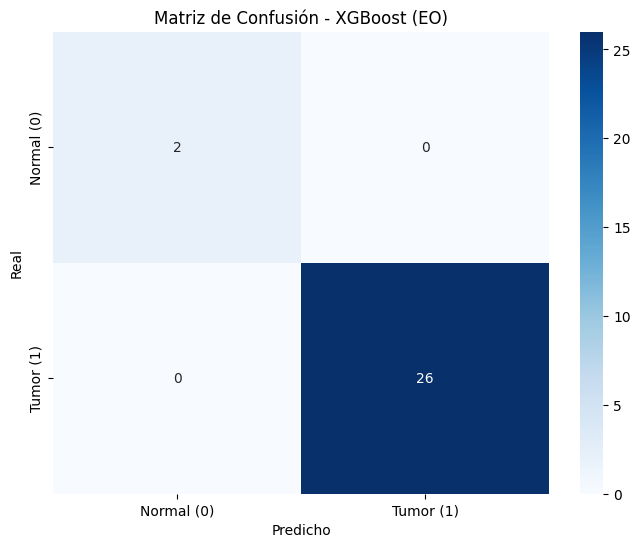


📊 Reporte de Clasificación detallado:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         2
       Tumor       1.00      1.00      1.00        26

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28



In [28]:
# 6. MATRIZ DE CONFUSIÓN PARA EL MEJOR MODELO
# ============================================
best_name = best_model[0]
best_y_pred = results[best_name]['y_pred']

cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Tumor (1)'],
            yticklabels=['Normal (0)', 'Tumor (1)'])
plt.title(f'Matriz de Confusión - XGBoost ({best_name})')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

print(f"\n📊 Reporte de Clasificación detallado:")
print(classification_report(y_test, best_y_pred, target_names=['Normal', 'Tumor']))

###Visualización de importancia de genes 🌺

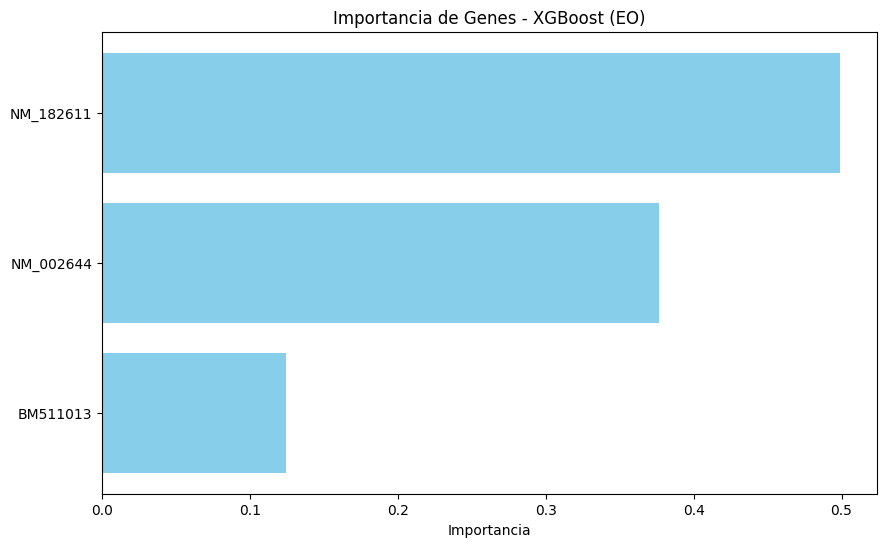

In [29]:
# 7. VISUALIZACIÓN DE IMPORTANCIA DE GENES (para el mejor modelo)
# ===============================================================
if best_name in results:
    imp_df = results[best_name]['feature_importance']
    plt.figure(figsize=(10, 6))
    plt.barh(imp_df['gene'], imp_df['importance'], color='skyblue')
    plt.xlabel('Importancia')
    plt.title(f'Importancia de Genes - XGBoost ({best_name})')
    plt.gca().invert_yaxis()
    plt.show()

###Comparación con los resultados del artículo 🌺

In [30]:
# 8. COMPARACIÓN CON LOS RESULTADOS DEL ARTÍCULO
# ===============================================
print(f"\n{'='*60}")
print("📚 COMPARACIÓN CON EL ARTÍCULO (Tabla 8)")
print('='*60)

print("\nResultados del artículo para XGBoost con EO:")
print("   Accuracy: 0.976 ± 0.027")
print("   F1-Score: 0.974 ± 0.030")
print("   AUC: 0.987 ± 0.025")

if 'EO' in results:
    print(f"\n📊 TUS RESULTADOS para XGBoost con EO:")
    print(f"   Test Accuracy: {results['EO']['test_accuracy']:.4f}")
    print(f"   Test F1: {results['EO']['test_f1']:.4f}")
    print(f"   Test AUC: {results['EO']['test_auc']:.4f}")
    print(f"   CV Accuracy: {results['EO']['cv_accuracy']}")

    # Pequeña comparación
    print(f"\n🔍 Análisis:")
    article_acc = 0.976
    your_acc = results['EO']['test_accuracy']
    diff = your_acc - article_acc
    if abs(diff) < 0.02:
        print(f"   ✅ Tus resultados son muy cercanos a los del artículo")
    elif your_acc > article_acc:
        print(f"   ⭐ ¡Superaste los resultados del artículo por {diff:.3f}!")
    else:
        print(f"   📉 Tus resultados están ligeramente por debajo del artículo ({diff:.3f})")


📚 COMPARACIÓN CON EL ARTÍCULO (Tabla 8)

Resultados del artículo para XGBoost con EO:
   Accuracy: 0.976 ± 0.027
   F1-Score: 0.974 ± 0.030
   AUC: 0.987 ± 0.025

📊 TUS RESULTADOS para XGBoost con EO:
   Test Accuracy: 1.0000
   Test F1: 1.0000
   Test AUC: 1.0000
   CV Accuracy: 0.9950 ± 0.0150

🔍 Análisis:
   ⭐ ¡Superaste los resultados del artículo por 0.024!


###Guardar resultados 🌺

In [31]:
# 9. GUARDAR RESULTADOS
# ======================
print(f"\n--- Guardando resultados de XGBoost ---")

# Guardar resultados completos
with open('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/results_xgboost.pkl', 'wb') as f:
    pickle.dump(results, f)

# Guardar predicciones del mejor modelo
np.save('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/xgboost_best_predictions.npy', best_y_pred)
np.save('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/xgboost_best_proba.npy', results[best_name]['y_proba'])

# Guardar modelo entrenado del mejor subset
xgb_model.fit(
    np.load(f'/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/train_{best_name}.npy'),
    y_train
)
xgb_model.save_model(f'/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/xgboost_{best_name}_model.json')

print(f"✅ Resultados guardados en Google Drive")
print(f"   - results_xgboost.pkl")
print(f"   - xgboost_best_predictions.npy")
print(f"   - xgboost_best_proba.npy")
print(f"   - xgboost_{best_name}_model.json")


--- Guardando resultados de XGBoost ---
✅ Resultados guardados en Google Drive
   - results_xgboost.pkl
   - xgboost_best_predictions.npy
   - xgboost_best_proba.npy
   - xgboost_EO_model.json
